In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.nn import knn_graph
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\Ahad\miniconda3\envs\jku_wad\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Ahad\miniconda3\envs\jku_wad\Lib\site-packages\torch_scatter\_version_cuda.pyd
  import torch_geometric.typing
c:\Users\Ahad\miniconda3\envs\jku_wad\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Ahad\miniconda3\envs\jku_wad\Lib\site-packages\torch_sparse\_version_cuda.pyd
  import torch_geometric.typing


Using device: cuda


## Dataset Synthesis and Graph Construction

We define the 7 base colors (ROYGBIV) and add random Gaussian noise to create continuous shades. Every image is converted into a graph $G = (V, E)$ where nodes are foreground pixels, features are $x_i = [p_x, p_y, r, g, b]$, and edges are formed using K-Nearest Neighbors based on spatial coordinates.


In [2]:
# Base ROYGBIV colors (normalized 0-1)
ROYGBIV = torch.tensor([
    [1.0, 0.0, 0.0],         # Red
    [1.0, 0.5, 0.0],         # Orange
    [1.0, 1.0, 0.0],         # Yellow
    [0.0, 1.0, 0.0],         # Green
    [0.0, 0.0, 1.0],         # Blue
    [0.29, 0.0, 0.51],       # Indigo
    [0.58, 0.0, 0.83]        # Violet
], dtype=torch.float)

def image_to_colored_graph(image_tensor, digit_label, k=8):
    """Converts a 28x28 grayscale image to a colored KNN graph."""
    # 1. Select Color and add noise (shade)
    color_idx = torch.randint(0, 7, (1,)).item()
    base_color = ROYGBIV[color_idx]
    noise = torch.randn(3) * 0.05 
    shaded_color = torch.clamp(base_color + noise, 0.0, 1.0)
    
    # 2. Extract foreground pixels (nodes)
    image = image_tensor.squeeze() # [28, 28]
    coords = torch.nonzero(image > 0.1).float() # [num_nodes, 2]
    
    # Handle empty graphs (though rare in MNIST)
    if coords.size(0) == 0:
        coords = torch.tensor([[14.0, 14.0]])
        
    # Normalize coordinates to [0, 1]
    coords = coords / 27.0 
    
    # 3. Create Node Features: [pos_x, pos_y, r, g, b]
    num_nodes = coords.size(0)
    colors_expanded = shaded_color.repeat(num_nodes, 1)
    x = torch.cat([coords, colors_expanded], dim=1) # [num_nodes, 5]
    
    # 4. Create Edges using KNN (connect spatially close pixels)
    edge_index = knn_graph(coords, k=k, loop=False)
    
    return Data(
        x=x, 
        edge_index=edge_index, 
        pos=coords, 
        y_digit=torch.tensor([digit_label], dtype=torch.long),
        y_color=torch.tensor([color_idx], dtype=torch.long)
    )

# Load standard MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# For demonstration, we use a subset of 5000 images to speed up local execution
subset_indices = torch.randperm(len(mnist_train))[:5000]
mnist_subset = Subset(mnist_train, subset_indices)

print("Converting images to graphs... This may take a minute.")
graph_dataset = [image_to_colored_graph(img, label) for img, label in mnist_subset]
train_loader = DataLoader(graph_dataset, batch_size=64, shuffle=True)
print(f"Created {len(graph_dataset)} graph samples.")


Converting images to graphs... This may take a minute.
Created 5000 graph samples.


C:\Users\Ahad\AppData\Local\Temp\ipykernel_16264\1547772308.py:57: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(graph_dataset, batch_size=64, shuffle=True)


## GNN Architecture

A Graph Attention Network (GAT) is used. The network computes a shared global embedding $h_G \in \mathbb{R}^{128}$, which is then passed to two parallel classification heads.


In [3]:
class DualHeadGAT(torch.nn.Module):
    def __init__(self, in_channels=5, hidden_channels=64, embedding_dim=128):
        super(DualHeadGAT, self).__init__()
        # Message Passing Layers
        self.conv1 = GATConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels)
        
        # Projection to Shared Vector Space
        self.proj = torch.nn.Linear(hidden_channels, embedding_dim)
        
        # Dual Classification Heads
        self.fc_digit = torch.nn.Linear(embedding_dim, 10) # 0-9
        self.fc_color = torch.nn.Linear(embedding_dim, 7)  # ROYGBIV

    def forward(self, x, edge_index, batch):
        # Node embeddings
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        
        # Global pooling (graph-level embedding)
        hg = global_mean_pool(x, batch) 
        
        # Shared Embedding Space
        shared_embedding = self.proj(hg)
        shared_embedding = F.relu(shared_embedding)
        
        # Predictions
        out_digit = self.fc_digit(shared_embedding)
        out_color = self.fc_color(shared_embedding)
        
        return out_digit, out_color, shared_embedding

model = DualHeadGAT().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Joint Training Loop

We optimize the sum of the Cross-Entropy losses for both the digit class and the color class. This forces the `shared_embedding` to organize topologically by both features.


In [4]:
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out_digit, out_color, _ = model(data.x, data.edge_index, data.batch)
        
        loss_digit = F.cross_entropy(out_digit, data.y_digit)
        loss_color = F.cross_entropy(out_color, data.y_color)
        
        # Joint Loss
        loss = loss_digit + loss_color 
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

epochs = 15
print("Starting training...")
for epoch in range(1, epochs + 1):
    loss = train()
    if epoch % 3 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}')


Starting training...
Epoch 001, Loss: 2.7208
Epoch 003, Loss: 2.3402
Epoch 006, Loss: 2.1483
Epoch 009, Loss: 2.0002
Epoch 012, Loss: 1.7654
Epoch 015, Loss: 1.5567


## Visualization: Extracting the Vector Space

We extract the 128-dimensional shared embeddings for the dataset and project them down to 2D using t-SNE. We generate two plots: one clustered by Digit, and one clustered by Color, to verify the multi-modal entanglement of the space.


Computing t-SNE reduction...


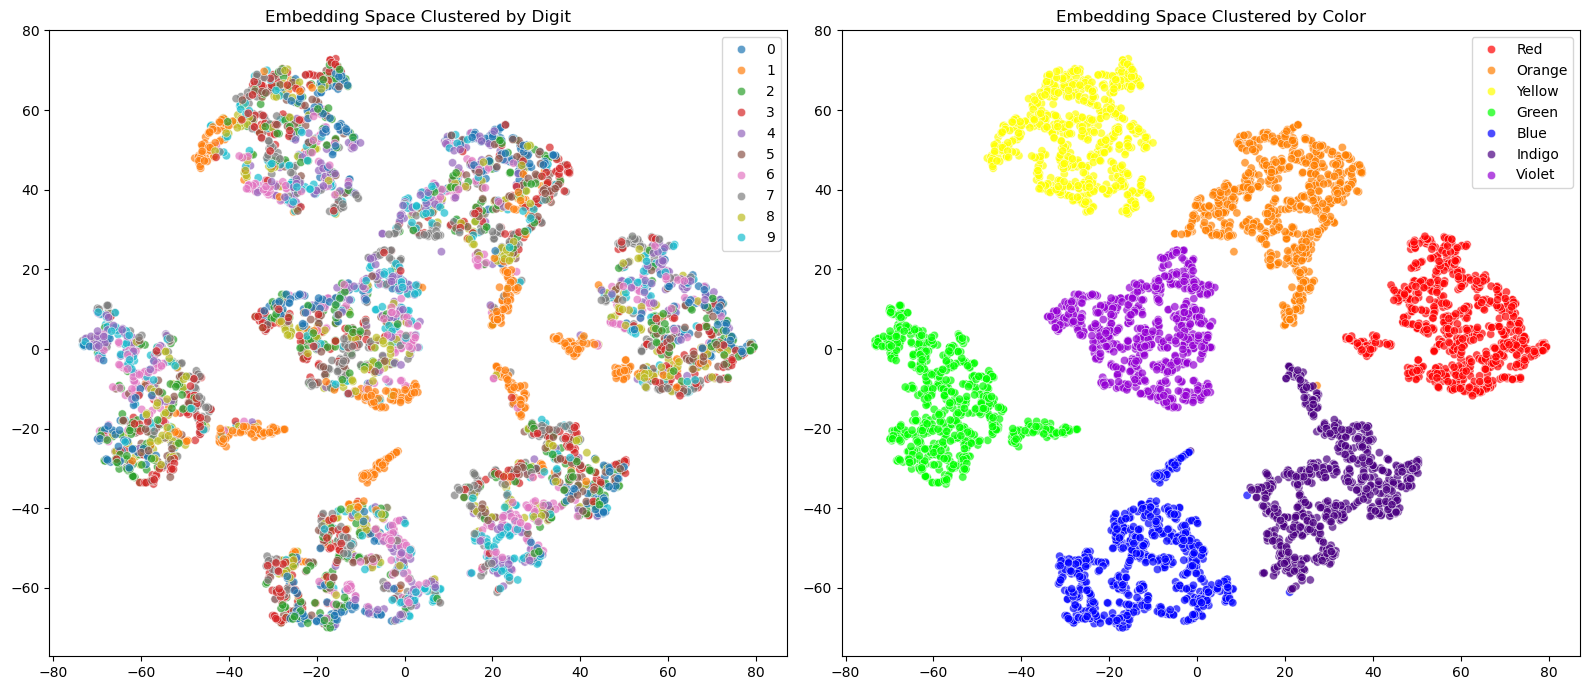

In [5]:
model.eval()
embeddings = []
digit_labels = []
color_labels = []

# Extract embeddings without gradients
with torch.no_grad():
    for data in train_loader:
        data = data.to(device)
        _, _, shared_emb = model(data.x, data.edge_index, data.batch)
        embeddings.append(shared_emb.cpu())
        digit_labels.append(data.y_digit.cpu())
        color_labels.append(data.y_color.cpu())

embeddings = torch.cat(embeddings, dim=0).numpy()
digit_labels = torch.cat(digit_labels, dim=0).numpy()
color_labels = torch.cat(color_labels, dim=0).numpy()

# Apply t-SNE
print("Computing t-SNE reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

# Plotting
color_names = ['Red', 'Orange', 'Yellow', 'Green', 'Blue', 'Indigo', 'Violet']
palette_colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00FF00', '#0000FF', '#4B0082', '#9400D3']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Clustered by Digit
sns.scatterplot(
    ax=axes[0],
    x=emb_2d[:, 0], y=emb_2d[:, 1],
    hue=digit_labels,
    palette=sns.color_palette("tab10", 10),
    legend="full", alpha=0.7
)
axes[0].set_title("Embedding Space Clustered by Digit")

# Plot 2: Clustered by Color
sns.scatterplot(
    ax=axes[1],
    x=emb_2d[:, 0], y=emb_2d[:, 1],
    hue=[color_names[i] for i in color_labels],
    palette=palette_colors,
    hue_order=color_names,
    legend="full", alpha=0.7
)
axes[1].set_title("Embedding Space Clustered by Color")

plt.tight_layout()
plt.show()